In [5]:
import json
import random
from sentence_transformers import SentenceTransformer
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
import pandas as pd
import textstat
import re
from better_profanity import profanity
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from textblob import TextBlob
import spacy
import seaborn as sns
from sklearn.model_selection import cross_val_score, StratifiedKFold, KFold, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import statsmodels.api as sm
from sklearn.linear_model import LinearRegression, LogisticRegression

In [6]:
df = pd.read_pickle("../data/data_final_features.pkl")
df.head()

,Index,author,body,normalizedBody,content,content_len,summary,summary_len,id,subreddit,...,content_sentiment,summary_sentiment,content_subjectivity,summary_subjectivity,delta_sentiment,delta_subjectivity,entity_retention_rate,content_pronoun_rate,summary_pronoun_rate,delta_pronoun_rate
0,90,Occamsrazor1,Every basic ecology class teaches this. The id...,Every basic ecology class teaches this. The id...,Every basic ecology class teaches this. The id...,112,We need to stop being such selfish bastards,8,c6hj5o3,science,...,0.2040,-0.8519,0.397338,0.75,-1.0559,0.352662,0.0,0.035398,0.125000,0.089602
1,91,Suddenfury,i was thinking about exactly this just yesterd...,i was thinking about exactly this just yesterd...,i was thinking about exactly this just yesterd...,148,why are the fishfarm industry so small scale?,8,c6hml12,science,...,0.6075,0.0000,0.480427,0.40,-0.6075,-0.080427,0.0,0.078947,0.000000,-0.078947
2,104,flutterbug32,One thing I have been told multiple times is t...,One thing I have been told multiple times is t...,One thing I have been told multiple times is t...,270,who you know is more helpful sometimes than wh...,11,c6rgfy8,ecology,...,0.9932,0.4754,0.482919,0.50,-0.5178,0.017081,0.0,0.132616,0.181818,0.049202
3,226,champyonfiyah,I'll take a crack at this. Starting with: ...,I'll take a crack at this. Starting with: ...,I'll take a crack at this. Starting with: ...,213,Yes you can do that with an arduino.,8,c6v4cup,arduino,...,0.9910,0.4019,0.542587,0.00,-0.5891,-0.542587,0.0,0.050459,0.125000,0.074541
4,300,Destructor1701,The *apparent* size - which is a function of s...,The apparent size - which is a function of s...,The apparent size - which is a function of s...,97,Distance matters only as part of the function ...,24,c71qcs8,space,...,0.2433,0.0258,0.550694,0.45,-0.2175,-0.100694,0.0,0.010309,0.000000,-0.010309


C:\Users\ludwi\AppData\Local\Temp\ipykernel_24208\3122457306.py:32: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")
C:\Users\ludwi\AppData\Local\Temp\ipykernel_24208\3122457306.py:51: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")


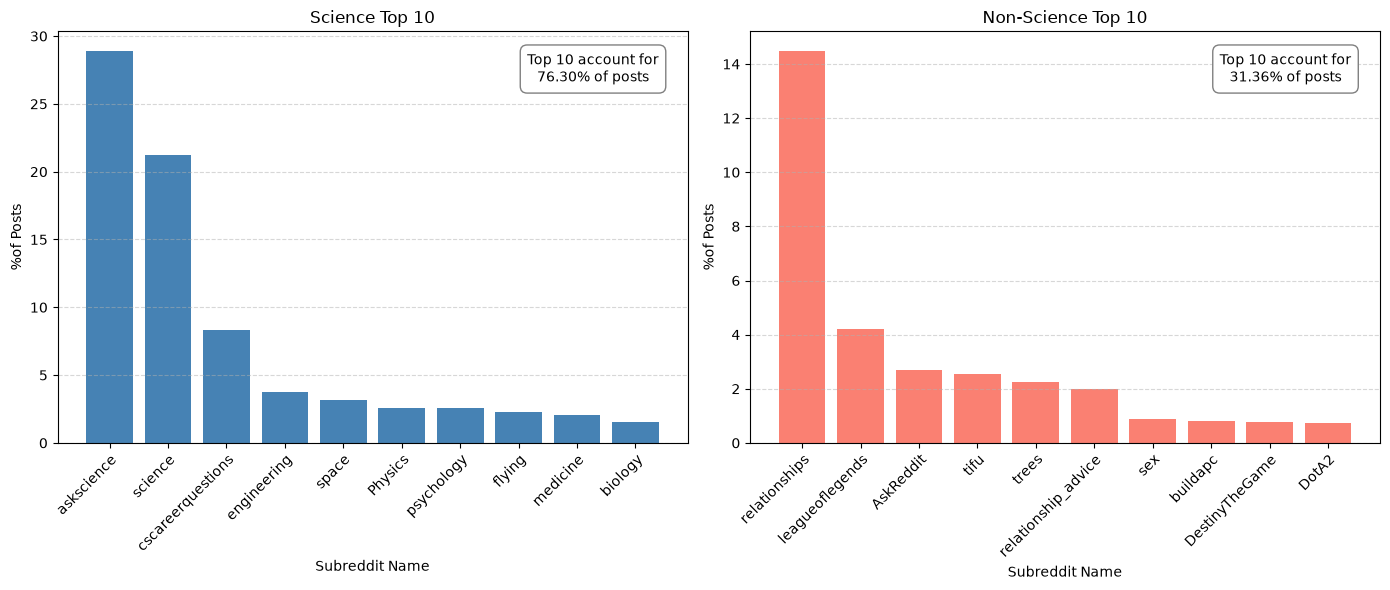

In [24]:
# Descriptive Statistics

# Largest subreddits: science vs. non-science
sci_subr_posts = {}
nonsci_subr_posts = {}

n_sci = len(df[df["is_science"]])
n_nonsci = len(df) - n_sci

for i, row in df.iterrows():
    subr_name = row["subreddit"]
    if row["is_science"]:
        sci_subr_posts[subr_name] = sci_subr_posts.get(subr_name, 0) + (100/n_sci)
    else:
        nonsci_subr_posts[subr_name] = nonsci_subr_posts.get(subr_name, 0) + (100/n_nonsci)


#sorting in descending usage order
sci_subr_posts = dict(sorted(sci_subr_posts.items(), key=lambda item: item[1], reverse=True))
nonsci_subr_posts = dict(sorted(nonsci_subr_posts.items(), key=lambda item: item[1], reverse=True))
#percentage of posts from top10 subreddits
sci_perc_top10 = sum(list(sci_subr_posts.values())[:10])
nonsci_perc_top10 = sum(list(nonsci_subr_posts.values())[:10])

sci_top = dict(sorted(sci_subr_posts.items(), key=lambda item: item[1], reverse=True)[:10])
nonsci_top = dict(sorted(nonsci_subr_posts.items(), key=lambda item: item[1], reverse=True)[:10])
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --- Left bar chart: sci ---
axes[0].bar(sci_top.keys(), sci_top.values(), color="steelblue")
axes[0].set_title("Science Top 10")
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")
axes[0].set_xlabel("Subreddit Name")
axes[0].set_ylabel("%of Posts")
axes[0].grid(axis = "y", ls = "--", alpha = 0.5)
axes[0].text(
    0.85, 0.95, f"Top 10 account for\n{sci_perc_top10:.2f}% of posts",
    transform=axes[0].transAxes,
    ha="center", va="top",
    fontsize=10,
    bbox=dict(
        facecolor="white",
        edgecolor="grey",
        boxstyle="round,pad=0.5"
    )
)

# --- Right bar chart: nonsci ---
axes[1].bar(nonsci_top.keys(), nonsci_top.values(), color="salmon")
axes[1].set_title("Non‑Science Top 10")
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")
axes[1].set_xlabel("Subreddit Name")
axes[1].set_ylabel("%of Posts")
axes[1].grid(axis = "y", ls = "--", alpha = 0.5)
axes[1].text(
    0.85, 0.95, f"Top 10 account for\n{nonsci_perc_top10:.2f}% of posts",
    transform=axes[1].transAxes,
    ha="center", va="top",
    fontsize=10,
    bbox=dict(
        facecolor="white",
        edgecolor="grey",
        boxstyle="round,pad=0.5"
    )
)

plt.tight_layout()
plt.show()

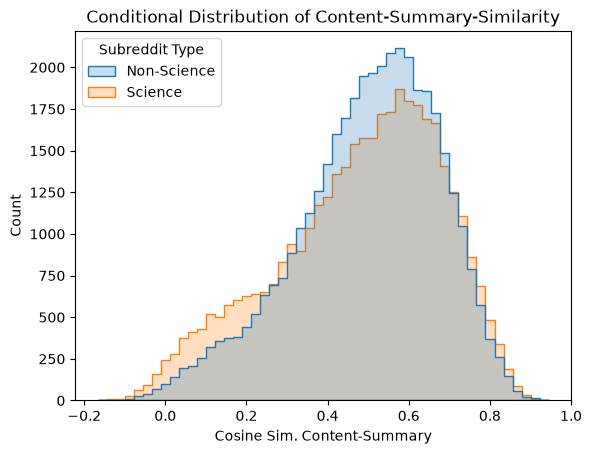

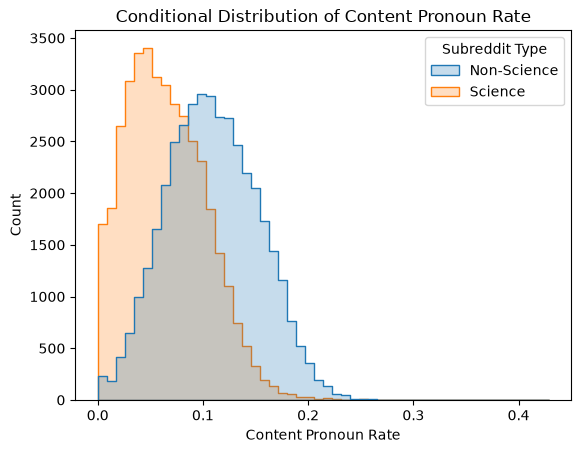

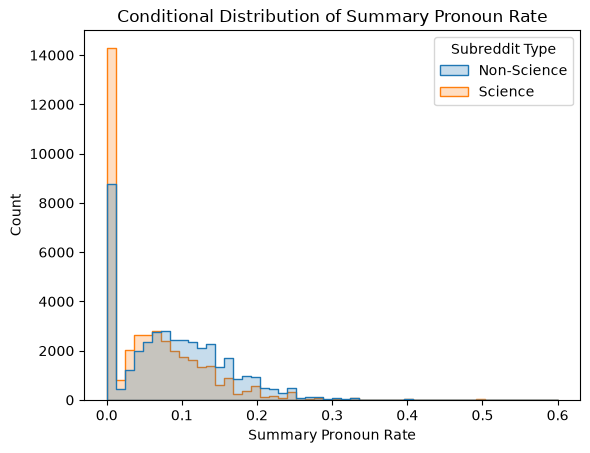

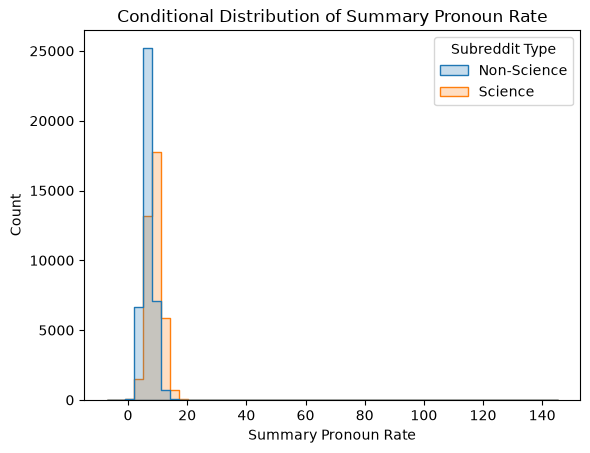

In [25]:
# conditional distributions based on is_science

# coleman liau
def cond_distr_plots(varname: str, xlabel: str, title: str):
    ax = sns.histplot(
        data=df,
        x=varname,
        hue='is_science', 
        element='step',      
        bins=50
    )
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel('Count')

    legend = ax.get_legend()
    legend.set_title("Subreddit Type")
    subr_labels = ["Non-Science", "Science"]
    for text, new_label in zip(legend.texts, subr_labels):
        text.set_text(new_label)
    plt.show()

cond_distr_plots("cosine_similarity", "Cosine Sim. Content-Summary", "Conditional Distribution of Content-Summary-Similarity")
cond_distr_plots("content_pronoun_rate", "Content Pronoun Rate", "Conditional Distribution of Content Pronoun Rate")
cond_distr_plots("summary_pronoun_rate", "Summary Pronoun Rate", "Conditional Distribution of Summary Pronoun Rate")
cond_distr_plots("content_coleman_liau", "Summary Pronoun Rate", "Conditional Distribution of Summary Pronoun Rate")


In [9]:
# def prepare_pie_data(freq_dict, top_n=10):
#     """
#     Convert a frequency dictionary into a sorted DataFrame
#     and aggregate all but the top_n terms into an 'Other' category.
#     """
#     df = pd.DataFrame(list(freq_dict.items()), columns=["term", "freq"])
#     df = df.sort_values("freq", ascending=False)

#     # Split into top terms and the rest
#     top = df.head(top_n)
#     other_sum = df.iloc[top_n:]["freq"].sum()

#     # Append "Other" if needed
#     if other_sum > 0:
#         top = pd.concat([
#             top,
#             pd.DataFrame([["Other", other_sum]], columns=["term", "freq"])
#         ], ignore_index=True)

#     return top


# def plot_two_pies(dict1, dict2, top_n=10, title1="Dictionary 1", title2="Dictionary 2"):
#     data1 = prepare_pie_data(dict1, top_n)
#     data2 = prepare_pie_data(dict2, top_n)

#     fig, axes = plt.subplots(1, 2, figsize=(14, 7))

#     # Pie chart 1
#     axes[0].pie(
#         data1["freq"],
#         labels=data1["term"],
#         autopct="%1.1f%%",
#         startangle=140
#     )
#     axes[0].set_title(title1)

#     # Pie chart 2
#     axes[1].pie(
#         data2["freq"],
#         labels=data2["term"],
#         autopct="%1.1f%%",
#         startangle=140
#     )
#     axes[1].set_title(title2)

#     plt.tight_layout()
#     plt.show()

# plot_two_pies(sci_subr_posts, nonsci_subr_posts, top_n = 10, title1 = "Science-related subreddits", title2 = "Non-science-related subreddits")

                              content_flesch_reading_ease  \
content_flesch_reading_ease                          1.00   
content_flesch_kincaid_grade                        -0.90   
content_gunning_fog                                 -0.89   
content_coleman_liau                                -0.85   

                              content_flesch_kincaid_grade  \
content_flesch_reading_ease                          -0.90   
content_flesch_kincaid_grade                          1.00   
content_gunning_fog                                   0.98   
content_coleman_liau                                  0.62   

                              content_gunning_fog  content_coleman_liau  
content_flesch_reading_ease                 -0.89                 -0.85  
content_flesch_kincaid_grade                 0.98                  0.62  
content_gunning_fog                          1.00                  0.62  
content_coleman_liau                         0.62                  1.00  


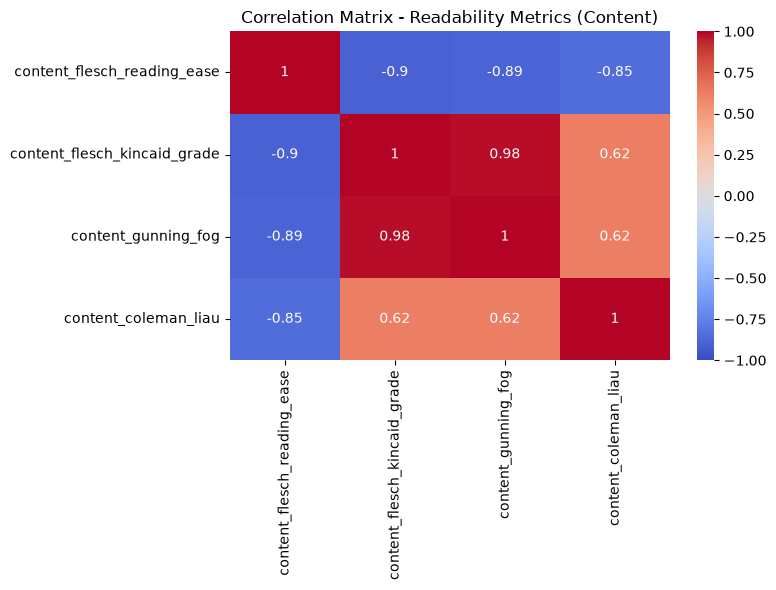

In [10]:
# check readability features again and select one

readability_cols = [
    'content_flesch_reading_ease', 'content_flesch_kincaid_grade',
    'content_gunning_fog', 'content_coleman_liau'
]

corr_matrix_readability = df[readability_cols].corr().round(2)
print(corr_matrix_readability)

# Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix_readability, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Matrix - Readability Metrics (Content)')
plt.tight_layout()
plt.show()

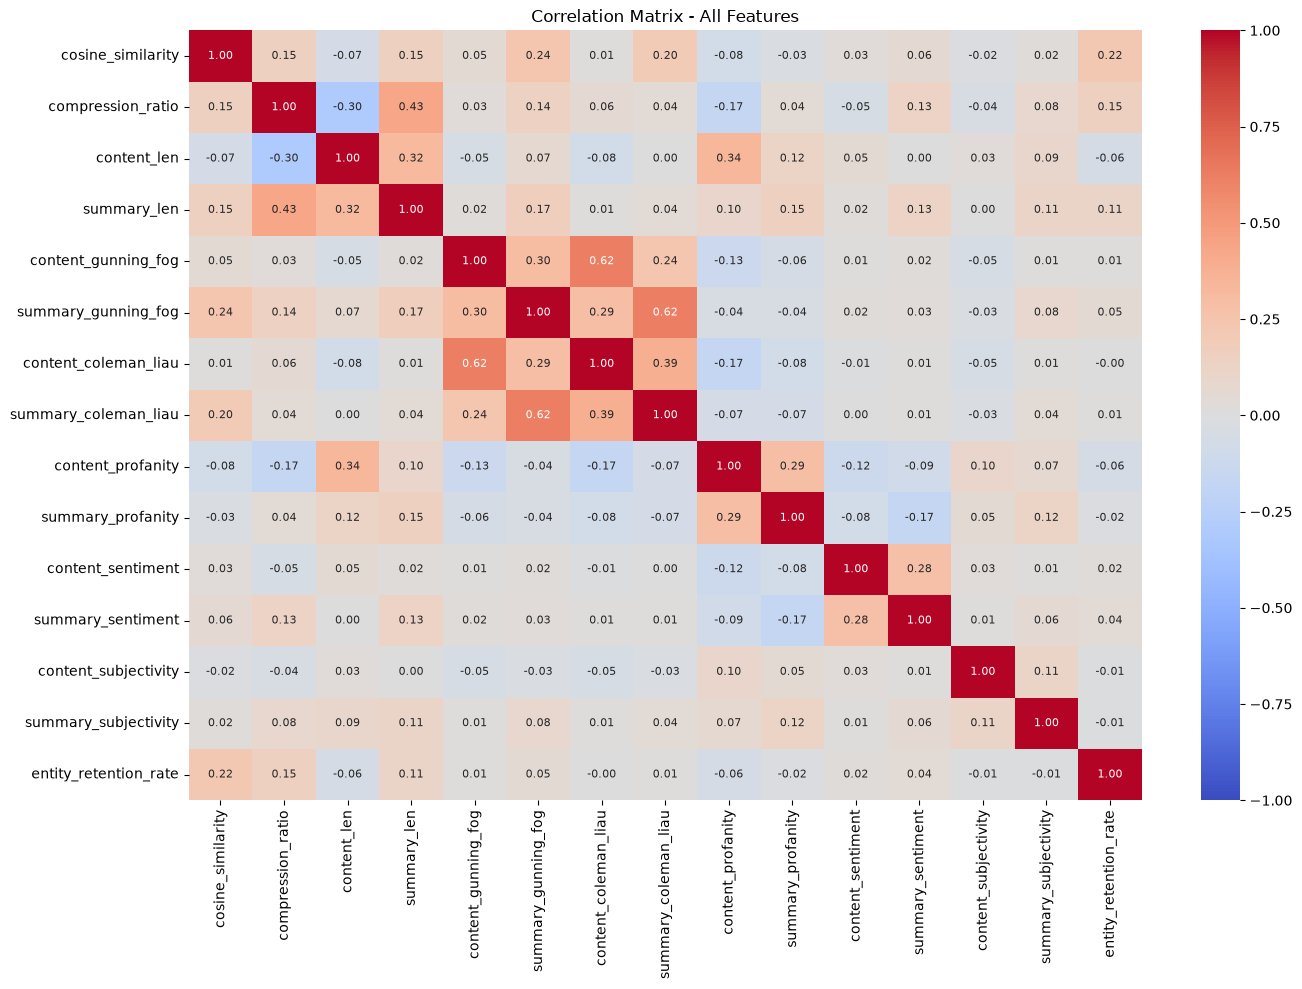

,cosine_similarity,compression_ratio,content_len,summary_len,content_gunning_fog,summary_gunning_fog,content_coleman_liau,summary_coleman_liau,content_profanity,summary_profanity,content_sentiment,summary_sentiment,content_subjectivity,summary_subjectivity,entity_retention_rate
cosine_similarity,1.00,0.15,-0.07,0.15,0.05,0.24,0.01,0.20,-0.08,-0.03,0.03,0.06,-0.02,0.02,0.22
compression_ratio,0.15,1.00,-0.30,0.43,0.03,0.14,0.06,0.04,-0.17,0.04,-0.05,0.13,-0.04,0.08,0.15
content_len,-0.07,-0.30,1.00,0.32,-0.05,0.07,-0.08,0.00,0.34,0.12,0.05,0.00,0.03,0.09,-0.06
summary_len,0.15,0.43,0.32,1.00,0.02,0.17,0.01,0.04,0.10,0.15,0.02,0.13,0.00,0.11,0.11
content_gunning_fog,0.05,0.03,-0.05,0.02,1.00,0.30,0.62,0.24,-0.13,-0.06,0.01,0.02,-0.05,0.01,0.01
summary_gunning_fog,0.24,0.14,0.07,0.17,0.30,1.00,0.29,0.62,-0.04,-0.04,0.02,0.03,-0.03,0.08,0.05
content_coleman_liau,0.01,0.06,-0.08,0.01,0.62,0.29,1.00,0.39,-0.17,-0.08,-0.01,0.01,-0.05,0.01,-0.00
summary_coleman_liau,0.20,0.04,0.00,0.04,0.24,0.62,0.39,1.00,-0.07,-0.07,0.00,0.01,-0.03,0.04,0.01
content_profanity,-0.08,-0.17,0.34,0.10,-0.13,-0.04,-0.17,-0.07,1.00,0.29,-0.12,-0.09,0.10,0.07,-0.06
summary_profanity,-0.03,0.04,0.12,0.15,-0.06,-0.04,-0.08,-0.07,0.29,1.00,-0.08,-0.17,0.05,0.12,-0.02


In [11]:
# check collinearity of other features
feature_cols = [
    'cosine_similarity', 'compression_ratio', 'content_len', 'summary_len',
    'content_gunning_fog', 'summary_gunning_fog',
    'content_coleman_liau', 'summary_coleman_liau',
    'content_profanity', 'summary_profanity',
    'content_sentiment', 'summary_sentiment',
    'content_subjectivity', 'summary_subjectivity',
    'entity_retention_rate'
]

corr_matrix = df[feature_cols].corr().round(2)

plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, 
            fmt='.2f', annot_kws={'size': 8})
plt.title('Correlation Matrix - All Features')
plt.tight_layout()
plt.show()
corr_matrix

In [12]:
FOLDS = 10

y = df["is_science"].astype(int)

colnames_summary = ["summary_len", "summary_gunning_fog", "summary_coleman_liau", "summary_profanity", "summary_sentiment", "summary_subjectivity", "summary_pronoun_rate"]
colnames_content = ["content_len", "content_gunning_fog", "content_coleman_liau", "content_profanity", "content_sentiment", "content_subjectivity", "content_pronoun_rate"]
colnames_full = colnames_content + colnames_summary + ["cosine_similarity", "entity_retention_rate"]

X_summary = df[colnames_summary]
X_content = df[colnames_content]
X_full = df[colnames_full]

pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegression(max_iter = 1000))
])

cv = StratifiedKFold(n_splits = FOLDS, shuffle = True, random_state = 42)

scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc",
}

summary_cv_results = cross_validate(pipeline, X_summary, y, cv=cv, scoring=scoring)
content_cv_results = cross_validate(pipeline, X_content, y, cv=cv, scoring=scoring)
full_cv_results = cross_validate(pipeline, X_full, y, cv=cv, scoring=scoring)

cv_df = pd.DataFrame({
    "Model": ["Summary only", "Content only", "Full"],
    "Accuracy": [summary_cv_results["test_accuracy"].mean(), content_cv_results["test_accuracy"].mean(), full_cv_results["test_accuracy"].mean()],
    "Precision": [summary_cv_results["test_precision"].mean(), content_cv_results["test_precision"].mean(), full_cv_results["test_precision"].mean()],
    "Recall": [summary_cv_results["test_recall"].mean(), content_cv_results["test_recall"].mean(), full_cv_results["test_recall"].mean()],
    "F1-Score": [summary_cv_results["test_f1"].mean(), content_cv_results["test_f1"].mean(), full_cv_results["test_f1"].mean()],
    "ROC-AUC": [summary_cv_results["test_roc_auc"].mean(), content_cv_results["test_roc_auc"].mean(), full_cv_results["test_roc_auc"].mean()]
}
)

display(cv_df)

# Model Summary

# standardizing
scaler = StandardScaler()
x_summary_scaled = pd.DataFrame(scaler.fit_transform(X_summary), columns = X_summary.columns, index = X_summary.index)
x_content_scaled = pd.DataFrame(scaler.fit_transform(X_content), columns = X_content.columns, index = X_content.index)
x_full_scaled = pd.DataFrame(scaler.fit_transform(X_full), columns = X_full.columns, index = X_full.index)

# adding oonstants
X_summary_sm = sm.add_constant(x_summary_scaled) 
X_content_sm = sm.add_constant(x_content_scaled) 
X_full_sm = sm.add_constant(x_full_scaled) 

# models:
logit_summary = sm.Logit(y, X_summary_sm)
logit_content = sm.Logit(y, X_content_sm)
logit_full = sm.Logit(y, X_full_sm)

# results
result_summary = logit_summary.fit()
result_content = logit_content.fit()
result_full = logit_full.fit()

print("\nLogit Model: Summary-only")
print(result_summary.summary())
print("|"*80)
print("\nLogit Model: Content-only")
print(result_content.summary())
print("|"*80)
print("\nLogit Model: Full")
print(result_full.summary())
print("|"*80)

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Summary only,0.625279,0.619934,0.627489,0.623677,0.674263
1,Content only,0.744566,0.741615,0.742522,0.742060,0.825053
2,Full,0.751361,0.750294,0.745738,0.747997,0.832143


Optimization terminated successfully.
         Current function value: 0.646993
         Iterations 6
Optimization terminated successfully.
         Current function value: 0.517133
         Iterations 6
Optimization terminated successfully.
         Current function value: 0.507879
         Iterations 6

Logit Model: Summary-only
                           Logit Regression Results                           
Dep. Variable:             is_science   No. Observations:                79179
Model:                          Logit   Df Residuals:                    79171
Method:                           MLE   Df Model:                            7
Date:                 Do, 02 Jul 2026   Pseudo R-squ.:                 0.06651
Time:                        08:39:06   Log-Likelihood:                -51228.
converged:                       True   LL-Null:                       -54878.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                           coef    

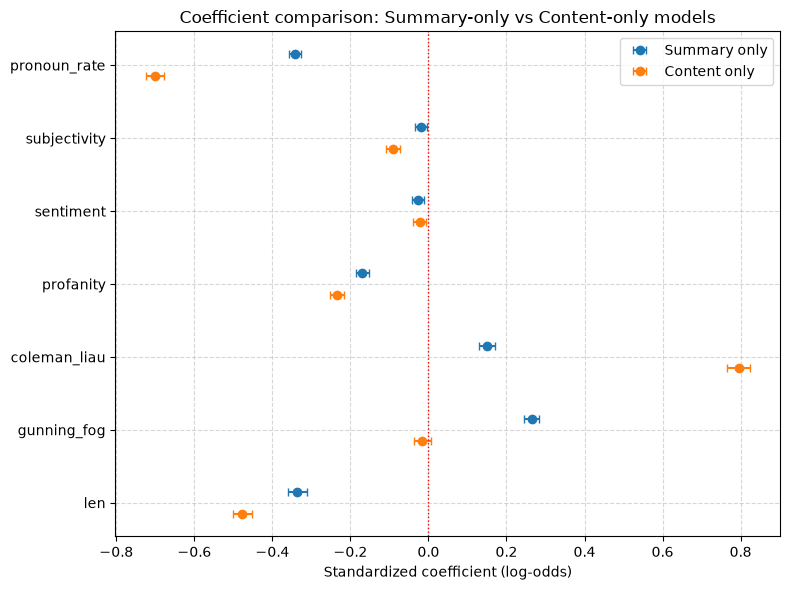

In [13]:
# Coefficient Plot: Comparing Summary-Only and Content-Only Models

def get_coef_df(result, prefix, model_name):
    """Pull coefficients + 95% CIs out of a fitted statsmodels result,
    drop the intercept, and strip the feature-name prefix so that
    e.g. 'summary_len' and 'content_len' both become 'len'."""
    conf = result.conf_int()
    conf.columns = ["ci_low", "ci_high"]
 
    coef_df = pd.DataFrame({
        "feature": result.params.index,
        "coef": result.params.values,
        "ci_low": conf["ci_low"].values,
        "ci_high": conf["ci_high"].values,
    })
 
    coef_df = coef_df[coef_df["feature"] != "const"]
    coef_df["feature"] = coef_df["feature"].str.replace(f"^{prefix}_", "", regex=True)
    coef_df["model"] = model_name
    return coef_df


summary_coefs = get_coef_df(result_summary, "summary", "Summary only")
content_coefs = get_coef_df(result_content, "content", "Content only")

coef_plot_df = pd.concat([summary_coefs, content_coefs], ignore_index=True)


feature_order = summary_coefs["feature"].tolist()
coef_plot_df["feature"] = pd.Categorical(
    coef_plot_df["feature"], categories=feature_order, ordered=True
)
coef_plot_df = coef_plot_df.sort_values("feature")


fig, ax = plt.subplots(figsize=(8, 6))
 
offset = 0.15
colors = {"Summary only": "#1f77b4", "Content only": "#ff7f0e"}
 
for model_name, shift in [("Summary only", offset), ("Content only", -offset)]:
    sub = coef_plot_df[coef_plot_df["model"] == model_name]
    y_positions = np.arange(len(sub)) + shift
    errors = [sub["coef"] - sub["ci_low"], sub["ci_high"] - sub["coef"]]
    ax.errorbar(
        sub["coef"], y_positions, xerr=errors,
        fmt="o", label=model_name, color=colors[model_name], capsize=3,
    )
 
ax.axvline(x=0, color="red", linestyle=":", linewidth=1)
ax.set_yticks(np.arange(len(feature_order)))
ax.set_yticklabels(feature_order)
ax.set_xlabel("Standardized coefficient (log-odds)")
ax.set_title("Coefficient comparison: Summary-only vs Content-only models")
ax.legend()
plt.grid(axis = "both", linestyle = "--", alpha = 0.5)
plt.tight_layout()
plt.show()

